<a href="https://colab.research.google.com/github/carlavilla/GIS/blob/main/PS4_GIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Environment Set Up

In [1]:
!pip install mapclassify

In [2]:
import os, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import geopandas as gpd

import mapclassify

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files

from google.colab.data_table import DataTable
DataTable.max_columns = 250

#Dataset 1: UFO Sightings in the US
UFO sighting reports to the National UFO Reporting Center for the year 2024. </br>

Source: [NUFORC Databank](https://nuforc.org/databank/) </br>
Data was sorted for USA sighting reports on the website and recorded onto an excel spreadsheet for this project. Since my interest is in attitudes towards UFO sightings in a given year, this dataset contains reports made in 2024, regardless of the actual supposed sighting of the object. That means that some of the sightings are from previous years and they were only reported in 2024; conversely, some of the sightings claimed to have occurred in 2024 are not included in this dataset and they were reported in 2025. Other interesting variables include date of sighting, city of report, shape of object, and alternative explanation for event. Although some events appear to be disproven, all reports are used as indicative of supernatural beliefs. </br>

##UFO Sighting Reports dataset comments:
Since dataset includes single entries of reports, the count for the number of reports in each state in 2024 was calculated. This count appears in python as a series, but this series will be used as the variable to merge with the map. </br>

In [3]:
! wget -q -O ufo2024.xlsx https://raw.githubusercontent.com/carlavilla/GIS/main/ufo2024.xlsx
ufo=pd.read_excel('ufo2024.xlsx', engine='openpyxl')

In [4]:
ufo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4034 entries, 0 to 4033
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Occurred     4034 non-null   datetime64[ns]
 1   City         3974 non-null   object        
 2   State        4034 non-null   object        
 3   Country      4034 non-null   object        
 4   Shape        4032 non-null   object        
 5   Summary      4034 non-null   object        
 6   Reported     4034 non-null   datetime64[ns]
 7   Media        1589 non-null   object        
 8   Explanation  1007 non-null   object        
dtypes: datetime64[ns](2), object(7)
memory usage: 283.8+ KB


In [5]:
#rename to match other datasets
#state = abbreviation
ufo.rename(columns={'State': 'state'}, inplace=True)

In [6]:
#getting the count by state
from collections import Counter
ufocount = ufo['state'].value_counts()
print(ufocount)

state
CA    418
FL    244
TX    228
NY    221
WA    190
AZ    175
PA    157
CO    137
NC    125
MI    117
OH    113
NJ    101
OR     98
MA     96
GA     91
VA     91
IL     87
MN     83
TN     75
IN     69
SC     62
WI     61
KY     60
UT     60
MD     60
MO     59
CT     54
ID     54
OK     51
AL     50
NV     50
LA     47
NM     46
ME     45
KS     39
MT     37
AR     35
IA     34
WV     31
MS     28
NH     25
SD     20
AK     18
VT     18
NE     18
DE     17
RI     15
HI     11
WY      6
DC      5
ND      2
Name: count, dtype: int64


In [7]:
#Getting the county by city
ufocity = ufo['City'].value_counts()
print(ufocity)

City
New York        48
Los Angeles     40
San Diego       24
Las Vegas       20
Spokane         19
                ..
Willow           1
Fairbanks        1
Dillingham       1
Palmer           1
Anchor Point     1
Name: count, Length: 2369, dtype: int64


In [8]:
ufo.head(5)
ufo.columns

,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation
0,2024-12-15 17:00:00,Chatanika,AK,USA,Formation,Saw 3 non moving lights that disappeared one a...,2024-12-31,NaN,NaN
1,2024-12-28 08:01:00,Meadow Lakes,AK,USA,Circle,Observed flashing light (after larger plane we...,2024-12-28,Y,Drone
2,2024-12-13 20:00:00,NaN,AK,USA,Chevron,Large V shaped triangle with white lights,2024-12-25,NaN,NaN
3,2024-12-19 23:30:00,Trapper Creek,AK,USA,Oval,Green glowing oval object the size of a school...,2024-12-24,Y,NaN
4,2024-11-02 23:30:00,Fox,AK,USA,Orb,Floating light that accelerated downwards into...,2024-12-22,NaN,NaN


Index(['Occurred', 'City', 'state', 'Country', 'Shape', 'Summary', 'Reported',
       'Media', 'Explanation'],
      dtype='object')

In [9]:
#combining to match map shapefile
ufo['combined'] = ufo[['City','state']].apply(lambda row: ', '.join(row.values.astype(str)), axis=1)
ufo.head()

,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation,combined
0,2024-12-15 17:00:00,Chatanika,AK,USA,Formation,Saw 3 non moving lights that disappeared one a...,2024-12-31,NaN,NaN,"Chatanika, AK"
1,2024-12-28 08:01:00,Meadow Lakes,AK,USA,Circle,Observed flashing light (after larger plane we...,2024-12-28,Y,Drone,"Meadow Lakes, AK"
2,2024-12-13 20:00:00,NaN,AK,USA,Chevron,Large V shaped triangle with white lights,2024-12-25,NaN,NaN,"nan, AK"
3,2024-12-19 23:30:00,Trapper Creek,AK,USA,Oval,Green glowing oval object the size of a school...,2024-12-24,Y,NaN,"Trapper Creek, AK"
4,2024-11-02 23:30:00,Fox,AK,USA,Orb,Floating light that accelerated downwards into...,2024-12-22,NaN,NaN,"Fox, AK"


In [10]:
#getting the count by city,state
ufo_city = ufo['combined'].value_counts()
print(ufo_city)
#note that count is greater than whe not combined, meaning that some cities with same name but in different stated got lumped together earlier

combined
New York, NY       48
Los Angeles, CA    40
San Diego, CA      24
Las Vegas, NV      20
Spokane, WA        19
                   ..
Morgantown, WV      1
Lansing, WV         1
Hurricane, WV       1
Martinsburg, WV     1
Vance, AL           1
Name: count, Length: 2688, dtype: int64


In [11]:
ufo2= pd.merge(ufo, ufo_city, on='combined',how='outer',indicator=True)
ufo2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4034 entries, 0 to 4033
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Occurred     4034 non-null   datetime64[ns]
 1   City         3974 non-null   object        
 2   state        4034 non-null   object        
 3   Country      4034 non-null   object        
 4   Shape        4032 non-null   object        
 5   Summary      4034 non-null   object        
 6   Reported     4034 non-null   datetime64[ns]
 7   Media        1589 non-null   object        
 8   Explanation  1007 non-null   object        
 9   combined     4034 non-null   object        
 10  count        4034 non-null   int64         
 11  _merge       4034 non-null   category      
dtypes: category(1), datetime64[ns](2), int64(1), object(8)
memory usage: 350.9+ KB


In [12]:
#if any unmerged cases on left-only, it would mean the City is present in in the ufo dataset but not in the count
ufo2._merge.value_counts()

,count
_merge,
both,4034
left_only,0
right_only,0


In [13]:
ufo3= pd.merge(ufo, ufo_city, on='combined',how='inner',indicator=True)
ufo3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4034 entries, 0 to 4033
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Occurred     4034 non-null   datetime64[ns]
 1   City         3974 non-null   object        
 2   state        4034 non-null   object        
 3   Country      4034 non-null   object        
 4   Shape        4032 non-null   object        
 5   Summary      4034 non-null   object        
 6   Reported     4034 non-null   datetime64[ns]
 7   Media        1589 non-null   object        
 8   Explanation  1007 non-null   object        
 9   combined     4034 non-null   object        
 10  count        4034 non-null   int64         
 11  _merge       4034 non-null   category      
dtypes: category(1), datetime64[ns](2), int64(1), object(8)
memory usage: 350.9+ KB


In [14]:
ufo3.rename(columns={'count': 'city_count'}, inplace=True)
ufo3.drop(columns=['_merge'], inplace=True)
ufo3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4034 entries, 0 to 4033
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Occurred     4034 non-null   datetime64[ns]
 1   City         3974 non-null   object        
 2   state        4034 non-null   object        
 3   Country      4034 non-null   object        
 4   Shape        4032 non-null   object        
 5   Summary      4034 non-null   object        
 6   Reported     4034 non-null   datetime64[ns]
 7   Media        1589 non-null   object        
 8   Explanation  1007 non-null   object        
 9   combined     4034 non-null   object        
 10  city_count   4034 non-null   int64         
dtypes: datetime64[ns](2), int64(1), object(8)
memory usage: 346.8+ KB


In [15]:
ufo3.head(15)

,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation,combined,city_count
0,2024-12-15 17:00:00,Chatanika,AK,USA,Formation,Saw 3 non moving lights that disappeared one a...,2024-12-31,NaN,NaN,"Chatanika, AK",1
1,2024-12-28 08:01:00,Meadow Lakes,AK,USA,Circle,Observed flashing light (after larger plane we...,2024-12-28,Y,Drone,"Meadow Lakes, AK",1
2,2024-12-13 20:00:00,NaN,AK,USA,Chevron,Large V shaped triangle with white lights,2024-12-25,NaN,NaN,"nan, AK",2
3,2024-12-19 23:30:00,Trapper Creek,AK,USA,Oval,Green glowing oval object the size of a school...,2024-12-24,Y,NaN,"Trapper Creek, AK",1
4,2024-11-02 23:30:00,Fox,AK,USA,Orb,Floating light that accelerated downwards into...,2024-12-22,NaN,NaN,"Fox, AK",1
5,2024-12-17 08:41:00,Anchorage,AK,USA,Orb,Pulsating orbs,2024-12-17,NaN,NaN,"Anchorage, AK",2
6,2024-12-16 18:53:00,Two Rivers,AK,USA,Orb,Three orbs first appear as if they're falling ...,2024-12-16,Y,NaN,"Two Rivers, AK",1
7,2024-11-13 18:50:00,Anchorage,AK,USA,Light,Orange light was seen moving through the sky a...,2024-11-13,NaN,NaN,"Anchorage, AK",2
8,1975-07-10 13:04:00,Ninilchik,AK,USA,Other,Covered the whole sky,2024-10-29,NaN,NaN,"Ninilchik, AK",1
9,2024-09-02 19:12:00,Wasilla,AK,USA,Rectangle,"It flew by so fast, black rectangular object",2024-10-15,Y,NaN,"Wasilla, AK",3


#Dataset 2: Haunted Places in the US
Haunted places in the US as recorded in the [Shadowlands Haunted Places Index](https://www.theshadowlands.net/places/), last updated in 2020.

Source: [Github Tidy Tuesday Database](https://github.com/rfordatascience/tidytuesday/blob/main/data/2023/2023-10-10/readme.md) </br>
Data was gathered by user [Tim Renner](https://github.com/timothyrenner/shadowlands-haunted-places) for a tidytuesday challenge. Other interesting variables include description of haunting/place, city, and latitutde/longitude of place.

##Haunted Places dataset comments:
Since dataset includes single entries of haunted places, the count for the number of places in each state was calculated. This count appears in python as a series, but this series will be used as the variable to merge with the map.

In [ ]:
haunted=pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-10/haunted_places.csv')

In [ ]:
haunted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            10989 non-null  object 
 1   country         10992 non-null  object 
 2   description     10992 non-null  object 
 3   location        10989 non-null  object 
 4   state           10992 non-null  object 
 5   state_abbrev    10992 non-null  object 
 6   longitude       9731 non-null   float64
 7   latitude        9731 non-null   float64
 8   city_longitude  10963 non-null  float64
 9   city_latitude   10963 non-null  float64
dtypes: float64(4), object(6)
memory usage: 858.9+ KB


In [ ]:
haunted.rename(columns={'state': 'state_name'}, inplace=True)
haunted.rename(columns={'state_abbrev': 'state'}, inplace=True)
#changing variable names so they can be used for merging later

In [ ]:
hauntedcount = haunted['state'].value_counts()
print(hauntedcount)

state
CA    1070
TX     696
PA     649
MI     529
OH     477
NY     459
IL     395
KY     370
IN     351
MA     342
FL     328
MO     314
GA     289
WI     274
AL     224
TN     221
WA     218
NC     211
OK     211
NJ     194
VA     192
CT     185
MD     170
IA     169
SC     168
CO     166
MN     162
AZ     156
OR     155
UT     134
KS     123
AR     119
NE     111
WV     106
LA      99
HI      96
NM      78
WY      76
SD      75
NH      72
RI      68
ID      66
VT      63
MS      63
ND      58
ME      57
NV      56
MT      42
DE      37
AK      32
DC      16
Name: count, dtype: int64


In [ ]:
hauntedcity = haunted['city'].value_counts()
print(hauntedcity)

city
Los Angeles           61
San Antonio           55
Honolulu              43
Pittsburgh            42
Columbus              41
                      ..
Tabernacle             1
Toms River             1
Tewksbury Township     1
Villas                 1
Port Monmouth          1
Name: count, Length: 4385, dtype: int64


In [ ]:
#combining to match map shapefile
haunted['combined'] = haunted[['city','state']].apply(lambda row: ', '.join(row.values.astype(str)), axis=1)
haunted.head()

,city,country,description,location,state_name,state,longitude,latitude,city_longitude,city_latitude,combined
0,Ada,United States,Ada witch - Sometimes you can see a misty blue...,Ada Cemetery,Michigan,MI,-85.504893,42.962106,-85.495480,42.960727,"Ada, MI"
1,Addison,United States,A little girl was killed suddenly while waitin...,North Adams Rd.,Michigan,MI,-84.381843,41.971425,-84.347168,41.986434,"Addison, MI"
2,Adrian,United States,If you take Gorman Rd. west towards Sand Creek...,Ghost Trestle,Michigan,MI,-84.035656,41.904538,-84.037166,41.897547,"Adrian, MI"
3,Adrian,United States,"In the 1970's, one room, room 211, in the old ...",Siena Heights University,Michigan,MI,-84.017565,41.905712,-84.037166,41.897547,"Adrian, MI"
4,Albion,United States,Kappa Delta Sorority - The Kappa Delta Sororit...,Albion College,Michigan,MI,-84.745177,42.244006,-84.753030,42.243097,"Albion, MI"


In [ ]:
haunted_city = haunted['combined'].value_counts()
print(haunted_city)

combined
Los Angeles, CA     61
San Antonio, TX     55
Honolulu, HI        43
Pittsburgh, PA      42
El Paso, TX         37
                    ..
Breckenridge, MI     1
Borculo, MI          1
Birmingham, MI       1
Berville, MI         1
Silver Cliff, CO     1
Name: count, Length: 5457, dtype: int64


In [ ]:
haunted2= pd.merge(haunted, haunted_city, on='combined',how='outer',indicator=True)
haunted2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   city            10989 non-null  object  
 1   country         10992 non-null  object  
 2   description     10992 non-null  object  
 3   location        10989 non-null  object  
 4   state_name      10992 non-null  object  
 5   state           10992 non-null  object  
 6   longitude       9731 non-null   float64 
 7   latitude        9731 non-null   float64 
 8   city_longitude  10963 non-null  float64 
 9   city_latitude   10963 non-null  float64 
 10  combined        10992 non-null  object  
 11  count           10992 non-null  int64   
 12  _merge          10992 non-null  category
dtypes: category(1), float64(4), int64(1), object(7)
memory usage: 1.0+ MB


In [ ]:
haunted2._merge.value_counts()
#no unmerged values- proceed with inner merge

,count
_merge,
both,10992
left_only,0
right_only,0


In [ ]:
haunted3= pd.merge(haunted, haunted_city, on='combined',how='inner',indicator=True)
haunted3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   city            10989 non-null  object  
 1   country         10992 non-null  object  
 2   description     10992 non-null  object  
 3   location        10989 non-null  object  
 4   state_name      10992 non-null  object  
 5   state           10992 non-null  object  
 6   longitude       9731 non-null   float64 
 7   latitude        9731 non-null   float64 
 8   city_longitude  10963 non-null  float64 
 9   city_latitude   10963 non-null  float64 
 10  combined        10992 non-null  object  
 11  count           10992 non-null  int64   
 12  _merge          10992 non-null  category
dtypes: category(1), float64(4), int64(1), object(7)
memory usage: 1.0+ MB


In [ ]:
haunted3.rename(columns={'count': 'hauntedcity_count'}, inplace=True)
haunted3.drop(columns=['_merge'], inplace=True)
haunted3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               10989 non-null  object 
 1   country            10992 non-null  object 
 2   description        10992 non-null  object 
 3   location           10989 non-null  object 
 4   state_name         10992 non-null  object 
 5   state              10992 non-null  object 
 6   longitude          9731 non-null   float64
 7   latitude           9731 non-null   float64
 8   city_longitude     10963 non-null  float64
 9   city_latitude      10963 non-null  float64
 10  combined           10992 non-null  object 
 11  hauntedcity_count  10992 non-null  int64  
dtypes: float64(4), int64(1), object(7)
memory usage: 1.0+ MB


In [ ]:
haunted3['latlong'] = haunted3[['latitude','longitude']].apply(lambda row: ', '.join(row.values.astype(str)), axis=1)
haunted3.head()

,city,country,description,location,state_name,state,longitude,latitude,city_longitude,city_latitude,combined,hauntedcity_count,latlong
0,Ada,United States,Ada witch - Sometimes you can see a misty blue...,Ada Cemetery,Michigan,MI,-85.504893,42.962106,-85.495480,42.960727,"Ada, MI",1,"42.9621061, -85.50489309999999"
1,Addison,United States,A little girl was killed suddenly while waitin...,North Adams Rd.,Michigan,MI,-84.381843,41.971425,-84.347168,41.986434,"Addison, MI",1,"41.9714248, -84.3818434"
2,Adrian,United States,If you take Gorman Rd. west towards Sand Creek...,Ghost Trestle,Michigan,MI,-84.035656,41.904538,-84.037166,41.897547,"Adrian, MI",2,"41.904538, -84.03565619999999"
3,Adrian,United States,"In the 1970's, one room, room 211, in the old ...",Siena Heights University,Michigan,MI,-84.017565,41.905712,-84.037166,41.897547,"Adrian, MI",2,"41.9057124, -84.0175653"
4,Albion,United States,Kappa Delta Sorority - The Kappa Delta Sororit...,Albion College,Michigan,MI,-84.745177,42.244006,-84.753030,42.243097,"Albion, MI",2,"42.2440064, -84.7451775"


#Dataset 3: US Elections Results 2024
Obtained from the [New York Times](https://github.com/nytimes/presidential-precinct-map-2024?tab=readme-ov-file#download-national-data)

In [ ]:
! wget -q -O cb_2018_us_cbsa_500k.zip https://github.com/carlavilla/GIS/raw/main/cb_2018_us_cbsa_500k.zip
#https://github.com/carlavilla/GIS/blob/e42e33864b940a375aa68b885da8d827dd44b999/cb_2018_us_cbsa_500k.zip
zip_ref = zipfile.ZipFile('cb_2018_us_cbsa_500k.zip', 'r'); zip_ref.extractall(); zip_ref.close()
USMetro=gpd.read_file('cb_2018_us_cbsa_500k.shp')

In [ ]:
#precincts-with-results.csv.gz

#Colorado Case Study

In [ ]:
ufo_co = ufo[ufo['state'] == 'CO']
display(ufo_co.head())

,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation,combined
696,2024-06-21 20:58:00,Thornton,CO,USA,Orb,We had witnessed at least six orbs being stati...,2024-12-31,Y,NaN,"Thornton, CO"
697,2024-08-21 22:50:00,Colorado Springs,CO,USA,Orb,I sent picture and videos to TV station KRDO. ...,2024-12-30,Y,Drone?,"Colorado Springs, CO"
698,2023-07-28 20:00:00,Ridgway,CO,USA,Unknown,No moving Massive Lights in arch shape,2024-12-28,Y,NaN,"Ridgway, CO"
699,2024-07-20 18:00:00,Denver,CO,USA,Cube,Very noticeable arc bright light very high in ...,2024-12-27,Y,NaN,"Denver, CO"
700,2024-12-20 04:00:00,Lakewood,CO,USA,Sphere,It was an orb that was moving closer and farth...,2024-12-21,NaN,NaN,"Lakewood, CO"


In [ ]:
from geopy.geocoders import Nominatim
#if you do a lot of geocoding: https://developers.google.com/maps/documentation/geocoding/overview

#change email addr!! they will blcok you!
geolocator = Nominatim(user_agent='tutu@gmail.com')
loc = geolocator.geocode("401 cooper st, camden nj 08102")
loc.address
loc[1]

'401, Cooper Street, Downtown, Camden, Camden County, New Jersey, 08102, United States'

(39.9472224, -75.1220198)

In [ ]:
import folium as f
from folium.plugins import MarkerCluster, HeatMap

import time

In [ ]:
ufo_co['combined'] = ufo_co[['City','state']].apply(lambda row: ', '.join(row.values.astype(str)), axis=1)
ufo_co.head()

/tmp/ipython-input-1115198508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ufo_co['combined'] = ufo_co[['City','state']].apply(lambda row: ', '.join(row.values.astype(str)), axis=1)


,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation,combined
696,2024-06-21 20:58:00,Thornton,CO,USA,Orb,We had witnessed at least six orbs being stati...,2024-12-31,Y,NaN,"Thornton, CO"
697,2024-08-21 22:50:00,Colorado Springs,CO,USA,Orb,I sent picture and videos to TV station KRDO. ...,2024-12-30,Y,Drone?,"Colorado Springs, CO"
698,2023-07-28 20:00:00,Ridgway,CO,USA,Unknown,No moving Massive Lights in arch shape,2024-12-28,Y,NaN,"Ridgway, CO"
699,2024-07-20 18:00:00,Denver,CO,USA,Cube,Very noticeable arc bright light very high in ...,2024-12-27,Y,NaN,"Denver, CO"
700,2024-12-20 04:00:00,Lakewood,CO,USA,Sphere,It was an orb that was moving closer and farth...,2024-12-21,NaN,NaN,"Lakewood, CO"


In [ ]:
ufo_co_test = ufo_co.head(10)
display(ufo_co_test)

,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation,combined
696,2024-06-21 20:58:00,Thornton,CO,USA,Orb,We had witnessed at least six orbs being stati...,2024-12-31,Y,NaN,"Thornton, CO"
697,2024-08-21 22:50:00,Colorado Springs,CO,USA,Orb,I sent picture and videos to TV station KRDO. ...,2024-12-30,Y,Drone?,"Colorado Springs, CO"
698,2023-07-28 20:00:00,Ridgway,CO,USA,Unknown,No moving Massive Lights in arch shape,2024-12-28,Y,NaN,"Ridgway, CO"
699,2024-07-20 18:00:00,Denver,CO,USA,Cube,Very noticeable arc bright light very high in ...,2024-12-27,Y,NaN,"Denver, CO"
700,2024-12-20 04:00:00,Lakewood,CO,USA,Sphere,It was an orb that was moving closer and farth...,2024-12-21,NaN,NaN,"Lakewood, CO"
701,2024-12-14 18:37:00,Denver,CO,USA,Orb,Multiple Orbs Following Same Path,2024-12-20,Y,NaN,"Denver, CO"
702,2024-07-21 22:35:00,Grand Junction,CO,USA,Triangle,Black triangle with three flashing white light...,2024-12-19,Y,Drone?,"Grand Junction, CO"
703,2024-12-14 20:30:00,Commerce City,CO,USA,Circle,Dozens of lights heading towards northern DIA ...,2024-12-18,NaN,NaN,"Commerce City, CO"
704,2024-12-18 03:12:00,Aurora,CO,USA,Orb,Was moving like a airplane at first then stopp...,2024-12-18,NaN,Drone?,"Aurora, CO"
705,2024-12-16 17:38:00,Elbert,CO,USA,Light,While driving on Walker road looking north spo...,2024-12-16,Y,Aircraft?,"Elbert, CO"


In [ ]:
import time
from geopy.geocoders import Nominatim

%%capture
# Re-initialize geolocator with a longer timeout
geolocator = Nominatim(user_agent='tutu@gmail.com', timeout=10)

m = f.Map(location=geolocator.geocode("colorado")[1], zoom_start=9)
for i in ufo_co_test.index:
  time.sleep(3) # Keep sleep time to mitigate rate limiting issues
  try:
    location = geolocator.geocode(ufo_co_test['combined'][i])
    if location:
      f.Marker(location[1], popup='Shape: '+ ufo_co_test['Shape'][i]).add_to(m)
    else:
      print(f"Could not geocode: {ufo_co_test['combined'][i]}")
  except Exception as e:
    print(f"Error geocoding {ufo_co_test['combined'][i]}: {e}")
#m.save('m7.html')
m

UsageError: Line magic function `%%capture` not found.


#US Map
United States map with metropolitan and micropolitan statistical areas, including Alaska and Hawaii.
Obtained from [US Census](https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html)

In [ ]:
! wget -q -O cb_2018_us_cbsa_500k.zip https://github.com/carlavilla/GIS/raw/main/cb_2018_us_cbsa_500k.zip
#https://github.com/carlavilla/GIS/blob/e42e33864b940a375aa68b885da8d827dd44b999/cb_2018_us_cbsa_500k.zip
zip_ref = zipfile.ZipFile('cb_2018_us_cbsa_500k.zip', 'r'); zip_ref.extractall(); zip_ref.close()
USMetro=gpd.read_file('cb_2018_us_cbsa_500k.shp')

In [ ]:
USMetro.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   CSAFP     537 non-null    object  
 1   CBSAFP    945 non-null    object  
 2   AFFGEOID  945 non-null    object  
 3   GEOID     945 non-null    object  
 4   NAME      945 non-null    object  
 5   LSAD      945 non-null    object  
 6   ALAND     945 non-null    int64   
 7   AWATER    945 non-null    int64   
 8   geometry  945 non-null    geometry
dtypes: geometry(1), int64(2), object(6)
memory usage: 66.6+ KB


In [ ]:
USMetro.head(5)

,CSAFP,CBSAFP,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,None,31340,310M400US31340,31340,"Lynchburg, VA",M1,5491925729,68559452,"POLYGON ((-79.8584 37.26715, -79.8566 37.26871..."
1,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7..."
2,None,24900,310M400US24900,24900,"Greenwood, MS",M2,3165909249,48172332,"POLYGON ((-90.45376 33.27626, -90.4531 33.3283..."
3,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684..."
4,None,18260,310M400US18260,18260,"Cookeville, TN",M2,2960951070,35466926,"POLYGON ((-85.84648 36.28817, -85.83735 36.341..."


In [ ]:
USMetro.rename(columns={'NAME': 'combined'}, inplace=True)
USMetro.head()

,CSAFP,CBSAFP,AFFGEOID,GEOID,combined,LSAD,ALAND,AWATER,geometry
0,None,31340,310M400US31340,31340,"Lynchburg, VA",M1,5491925729,68559452,"POLYGON ((-79.8584 37.26715, -79.8566 37.26871..."
1,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7..."
2,None,24900,310M400US24900,24900,"Greenwood, MS",M2,3165909249,48172332,"POLYGON ((-90.45376 33.27626, -90.4531 33.3283..."
3,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684..."
4,None,18260,310M400US18260,18260,"Cookeville, TN",M2,2960951070,35466926,"POLYGON ((-85.84648 36.28817, -85.83735 36.341..."


<Axes: >

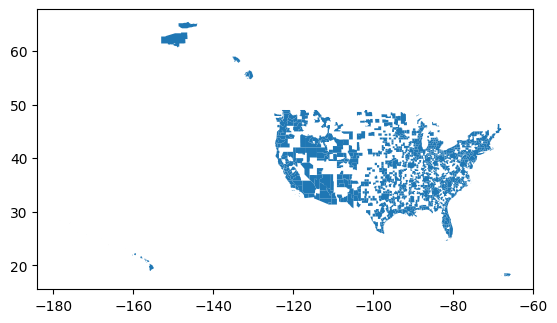

In [ ]:
USMetro.plot()
plt.show()

##Merging UFO

In [ ]:
ufo_US = pd.merge(USMetro, ufo3, on='combined',how='outer',indicator=True) #outer merging
ufo_US.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4705 entries, 0 to 4704
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CSAFP        713 non-null    object        
 1   CBSAFP       1204 non-null   object        
 2   AFFGEOID     1204 non-null   object        
 3   GEOID        1204 non-null   object        
 4   combined     4705 non-null   object        
 5   LSAD         1204 non-null   object        
 6   ALAND        1204 non-null   float64       
 7   AWATER       1204 non-null   float64       
 8   geometry     1204 non-null   geometry      
 9   Occurred     4034 non-null   datetime64[ns]
 10  City         3974 non-null   object        
 11  state        4034 non-null   object        
 12  Country      4034 non-null   object        
 13  Shape        4032 non-null   object        
 14  Summary      4034 non-null   object        
 15  Reported     4034 non-null   datetime64[ns]
 16

In [ ]:
ufo_US._merge.value_counts()
#left_only merge indicates that the city exists in the shapefile but there is no corresponding city with a UFO sighting. It is ok for this not to merge as not all cities have reported sighting for 2024.
#right_only merge indicates the city with the UFO sighting was not in the map. Will run a check for right_only values to examine closer.

,count
_merge,
right_only,3501
left_only,671
both,533


In [ ]:
ufo_US_check= ufo_US[['GEOID','combined', 'City', 'state', '_merge']]
display(ufo_US_check[ufo_US_check['_merge'] == 'right_only'])
#There are too many values to check completely, but it seems that the Cites from the ufo dataset that did not merge are simply not on the shapefile from the US Census, as opposed to a misspelling
#Note that some reports only have a state listed and no city, which naturally does not have a match in the shapefile.
#We'll continue with this merge and acknowledge the lack of data in the map and ufo dataset as a limitations.

,GEOID,combined,City,state,_merge
0,NaN,"Abbeville, MS",Abbeville,MS,right_only
4,NaN,"Abingdon, MD",Abingdon,MD,right_only
5,NaN,"Abita Springs, LA",Abita Springs,LA,right_only
7,NaN,"Addison, TX",Addison,TX,right_only
8,NaN,"Addison, TX",Addison,TX,right_only
...,...,...,...,...,...
4700,NaN,"nan, UT",NaN,UT,right_only
4701,NaN,"nan, VA",NaN,VA,right_only
4702,NaN,"nan, VA",NaN,VA,right_only
4703,NaN,"nan, VA",NaN,VA,right_only


In [ ]:
ufo_US = pd.merge(USMetro, ufo3, on='combined',how='inner',indicator=True)
ufo_US.head(10)

,CSAFP,CBSAFP,AFFGEOID,GEOID,combined,LSAD,ALAND,AWATER,geometry,Occurred,City,state,Country,Shape,Summary,Reported,Media,Explanation,city_count,_merge
0,None,31340,310M400US31340,31340,"Lynchburg, VA",M1,5491925729,68559452,"POLYGON ((-79.8584 37.26715, -79.8566 37.26871...",2024-08-09 22:30:00,Lynchburg,VA,USA,Light,Seen 4 separate times in past 2 weeks. It is n...,2024-08-09,Y,NaN,1,both
1,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7...",2024-12-23 19:30:00,Santa Rosa,CA,USA,Circle,Flashing light,2024-12-23,Y,NaN,6,both
2,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7...",2024-12-07 21:40:00,Santa Rosa,CA,USA,Circle,I looked up and coming from the north was 5 re...,2024-12-14,NaN,NaN,6,both
3,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7...",2024-10-28 02:53:00,Santa Rosa,CA,USA,Changing,Cluster of lights visible in peripheral vision...,2024-10-28,Y,Planet/Star,6,both
4,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7...",2024-10-16 21:55:00,Santa Rosa,CA,USA,Unknown,Three lights in a row,2024-10-17,Y,NaN,6,both
5,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7...",2024-10-14 11:30:00,Santa Rosa,CA,USA,Chevron,I was looking out my bedroom window when I saw...,2024-10-15,NaN,NaN,6,both
6,488,42220,310M400US42220,42220,"Santa Rosa, CA",M1,4081491107,497455304,"POLYGON ((-123.53354 38.76841, -123.52851 38.7...",2024-04-09 21:00:00,Santa Rosa,CA,USA,Changing,Rotating Circling App 15000 Feet Above 1345 Wh...,2024-04-10,Y,NaN,6,both
7,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",2024-12-14 19:08:00,Tulsa,OK,USA,Orb,"7:08 PM, 3 lights moving in pattern of ease, h...",2024-12-15,NaN,NaN,4,both
8,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",2022-04-22 19:00:00,Tulsa,OK,USA,Cube,"Cube Sighting with 6 friends, resulting in an ...",2024-10-03,NaN,NaN,4,both
9,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",2024-04-12 20:31:00,Tulsa,OK,USA,Changing,Bright flash in the sky. Then light dimmed to ...,2024-04-12,NaN,NaN,4,both


##Merging Haunted

In [ ]:
haunted_US = pd.merge(USMetro, haunted3, on='combined',how='outer',indicator=True) #outer merging
haunted_US.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11440 entries, 0 to 11439
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CSAFP              1478 non-null   object  
 1   CBSAFP             2426 non-null   object  
 2   AFFGEOID           2426 non-null   object  
 3   GEOID              2426 non-null   object  
 4   combined           11440 non-null  object  
 5   LSAD               2426 non-null   object  
 6   ALAND              2426 non-null   float64 
 7   AWATER             2426 non-null   float64 
 8   geometry           2426 non-null   geometry
 9   city               10989 non-null  object  
 10  country            10992 non-null  object  
 11  description        10992 non-null  object  
 12  location           10989 non-null  object  
 13  state_name         10992 non-null  object  
 14  state              10992 non-null  object  
 15  longitude          9731 non-null   float64 
 

In [ ]:
haunted_US._merge.value_counts()
#left_only merge indicates that the city exists in the shapefile but there is no corresponding city with a haunted place. It is ok for this not to merge as not all cities have a haunted palce
#right_only merge indicates the city with the haunted place was not in the map. Will run a check for right_only values to examine closer.

,count
_merge,
right_only,9014
both,1978
left_only,448


In [ ]:
haunted_US_check= haunted_US[['GEOID','combined', 'city', 'state', '_merge']]
display(haunted_US_check[haunted_US_check['_merge'] == 'right_only'])
#there appear to be inconsistencies in the haunted data set, ranging for capitalization discrepancies to missing cities.
#Normally we would attempt to correct the discrepancies; however, we'll proceed with inner merging aware of this limitation.

,GEOID,combined,city,state,_merge
0,NaN,"<>Manteca, CA",<>Manteca,CA,right_only
1,NaN,"ARNOLD, MO",ARNOLD,MO,right_only
2,NaN,"Abbeville, SC",Abbeville,SC,right_only
3,NaN,"Abercrombie, ND",Abercrombie,ND,right_only
4,NaN,"Aberdeen, MD",Aberdeen,MD,right_only
...,...,...,...,...,...
11435,NaN,"nan, MI",NaN,MI,right_only
11436,NaN,"nan, OH",NaN,OH,right_only
11437,NaN,"sumter, SC",sumter,SC,right_only
11438,NaN,"the plains, VA",the plains,VA,right_only


In [ ]:
haunted_US = pd.merge(USMetro, haunted3, on='combined',how='inner',indicator=True)
haunted_US.head(10)

,CSAFP,CBSAFP,AFFGEOID,GEOID,combined,LSAD,ALAND,AWATER,geometry,city,...,location,state_name,state,longitude,latitude,city_longitude,city_latitude,hauntedcity_count,latlong,_merge
0,None,31340,310M400US31340,31340,"Lynchburg, VA",M1,5491925729,68559452,"POLYGON ((-79.8584 37.26715, -79.8566 37.26871...",Lynchburg,...,Randolph,Virginia,VA,-79.172197,37.436964,-79.142246,37.413754,2,"37.436964, -79.172197",both
1,None,31340,310M400US31340,31340,"Lynchburg, VA",M1,5491925729,68559452,"POLYGON ((-79.8584 37.26715, -79.8566 37.26871...",Lynchburg,...,William Bass Elementary School,Virginia,VA,-79.141076,37.391813,-79.142246,37.413754,2,"37.3918131, -79.141076",both
2,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Brady Theatre,Oklahoma,OK,-95.995391,36.158095,-95.992775,36.153982,12,"36.1580954, -95.9953915",both
3,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Camelot Hotel,Oklahoma,OK,-95.952074,36.147635,-95.992775,36.153982,12,"36.1476347, -95.9520741",both
4,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Old Central High School,Oklahoma,OK,-96.027117,36.162906,-95.992775,36.153982,12,"36.162906, -96.0271166",both
5,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,E. Easton Pl.,Oklahoma,OK,-95.896743,36.163427,-95.992775,36.153982,12,"36.1634272, -95.8967434",both
6,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Gilcrease Museum,Oklahoma,OK,-96.020613,36.173972,-95.992775,36.153982,12,"36.1739715, -96.0206134",both
7,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Memorial Cemetery,Oklahoma,OK,-95.885304,36.088678,-95.992775,36.153982,12,"36.0886776, -95.8853044",both
8,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Mohawk park,Oklahoma,OK,-95.893393,36.221145,-95.992775,36.153982,12,"36.2211445, -95.8933926",both
9,538,46140,310M400US46140,46140,"Tulsa, OK",M1,16238554204,492994165,"POLYGON ((-97.06448 36.68106, -97.06411 36.684...",Tulsa,...,Mohawk park golf course,Oklahoma,OK,-95.917307,36.214925,-95.992775,36.153982,12,"36.214925, -95.917307",both


#Mapping

In [ ]:
ufo_UScent = ufo_US.copy()

ufo_UScent["geometry"] = ufo_UScent["geometry"].centroid

/tmp/ipython-input-2535557320.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ufo_UScent["geometry"] = ufo_UScent["geometry"].centroid


<Axes: >

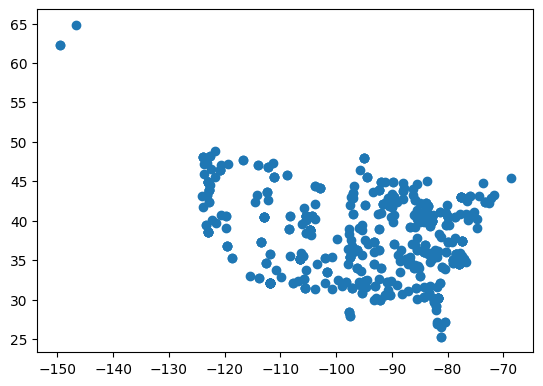

In [ ]:
ufo_UScent.plot()
plt.show()

<Axes: >

[]

[]

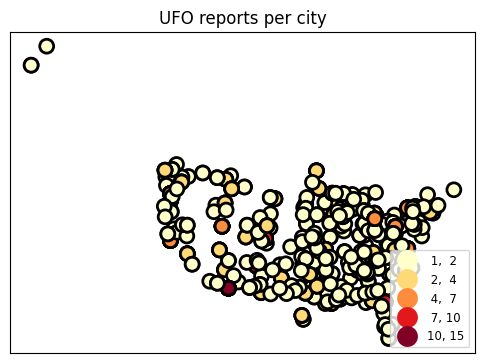

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
ufo_UScent.plot(ax=ax,column='city_count',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.5},
         markersize = 100) #
ax.title.set_text("UFO reports per city")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
haunted_UScent = haunted_US.copy()

haunted_UScent["geometry"] = haunted_UScent["geometry"].centroid

/tmp/ipython-input-839199035.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  haunted_UScent["geometry"] = haunted_UScent["geometry"].centroid


<Axes: >

[]

[]

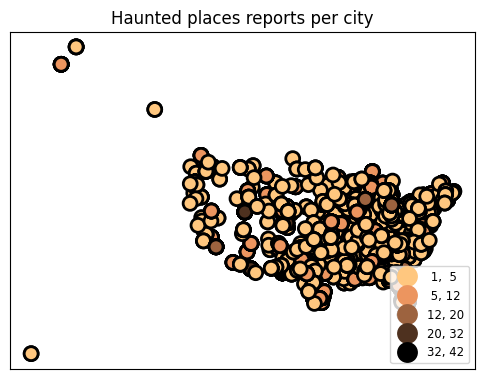

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
haunted_UScent.plot(ax=ax,column='hauntedcity_count',legend=True,cmap='copper_r',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.5},
         markersize = 100) #
ax.title.set_text("Haunted places reports per city")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
'''
import folium
min_lon, max_lon = -125, -66
min_lat, max_lat = 24, 50


combo_map = ufo_UScent.explore(
    column="city_count",
    cmap= "winter_r",
    scheme="equal_interval",  # use mapclassify's equal interval scheme
    k=5,
    legend=True,  # show legend
    tooltip=False,  # hide tooltip
    popup=["combined", "city_count"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="UFO Reports per City",  # name of the layer in the map
    scale=True,
    max_bounds=True,
    location=[-100, 35],
    zoom_start=6,
    min_lat=min_lat,
    max_lat=max_lat,
    min_lon=min_lon,
    max_lon=max_lon,
)

haunted_UScent.explore(
    column="hauntedcity_count",
    cmap= "copper_r",
    scheme="equal_interval",  # use mapclassify's equal interval scheme
    k=5,
    legend=True,  # show legend
    tooltip=False,  # hide tooltip
    popup=["combined", "hauntedcity_count"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="Haunted Places per City",  # name of the layer in the map
    scale=True,
    max_bounds=True,
    location=[-100, 35],
    zoom_start=6,
    min_lat=min_lat,
    max_lat=max_lat,
    min_lon=min_lon,
    max_lon=max_lon)
fg = folium.FeatureGroup(name="Haunted Places", show=False).add_to(combo_map)
folium.Marker(location=(0, 0)).add_to(fg)
folium.LayerControl().add_to(combo_map)

combo_map  # show map
'''

'\nimport folium\nmin_lon, max_lon = -125, -66\nmin_lat, max_lat = 24, 50\n\n\ncombo_map = ufo_UScent.explore(\n    column="city_count",\n    cmap= "winter_r",\n    scheme="equal_interval",  # use mapclassify\'s equal interval scheme\n    k=5,\n    legend=True,  # show legend\n    tooltip=False,  # hide tooltip\n    popup=["combined", "city_count"],  # show popup (on-click)\n    legend_kwds=dict(colorbar=False),  # do not use colorbar\n    name="UFO Reports per City",  # name of the layer in the map\n    scale=True,\n    max_bounds=True,\n    location=[-100, 35],\n    zoom_start=6,\n    min_lat=min_lat,\n    max_lat=max_lat,\n    min_lon=min_lon,\n    max_lon=max_lon,\n)\n\nhaunted_UScent.explore(\n    column="hauntedcity_count",\n    cmap= "copper_r",\n    scheme="equal_interval",  # use mapclassify\'s equal interval scheme\n    k=5,\n    legend=True,  # show legend\n    tooltip=False,  # hide tooltip\n    popup=["combined", "hauntedcity_count"],  # show popup (on-click)\n    legend_k

In [ ]:
%%capture
min_lon, max_lon = -125, -66
min_lat, max_lat = 24, 50


ufo_map = ufo_US.explore(
    column="city_count",
    cmap= "winter_r",
    scheme="equal_interval",  # use mapclassify's equal interval scheme
    k=5,
    legend=True,  # show legend
    tooltip=True,  # hide tooltip
    popup=["combined", "city_count"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="UFO Reports per City",  # name of the layer in the map
    scale=True,
    max_bounds=True,
    location=[-100, 35],
    zoom_start=6,
    min_lat=min_lat,
    max_lat=max_lat,
    min_lon=min_lon,
    max_lon=max_lon,
)

ufo_map  # show map

In [ ]:
%%capture
min_lon, max_lon = -125, -66
min_lat, max_lat = 24, 50


m = haunted_US.explore(
    column="hauntedcity_count",
    cmap= "copper_r",
    scheme="equal_interval",  # use mapclassify's equal interval scheme
    k=5,
    legend=True,  # show legend
    tooltip=False,  # hide tooltip
    popup=["combined", "hauntedcity_count"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="Haunted Places per City",  # name of the layer in the map
    scale=True,
    max_bounds=True,
    location=[-100, 35],
    zoom_start=6,
    min_lat=min_lat,
    max_lat=max_lat,
    min_lon=min_lon,
    max_lon=max_lon,
)

m  # show map

In [ ]:
haunted_UStest = pd.merge(USMetro, haunted, on='combined',how='inner',indicator=True) #outer merging
haunted_UStest.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1978 entries, 0 to 1977
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   CSAFP           1211 non-null   object  
 1   CBSAFP          1978 non-null   object  
 2   AFFGEOID        1978 non-null   object  
 3   GEOID           1978 non-null   object  
 4   combined        1978 non-null   object  
 5   LSAD            1978 non-null   object  
 6   ALAND           1978 non-null   int64   
 7   AWATER          1978 non-null   int64   
 8   geometry        1978 non-null   geometry
 9   city            1978 non-null   object  
 10  country         1978 non-null   object  
 11  description     1978 non-null   object  
 12  location        1978 non-null   object  
 13  state_name      1978 non-null   object  
 14  state           1978 non-null   object  
 15  longitude       1789 non-null   float64 
 16  latitude        1789 non-null   float64 
 17  city_l

In [ ]:
haunted_UStest._merge.value_counts()

,count
_merge,
both,1978
left_only,0
right_only,0


In [ ]:
%%capture
#not sure why it isn't showing
#obtained from https://stackoverflow.com/questions/39401729/plot-latitude-longitude-points-from-dataframe-on-folium-map-ipython and Gemini
import os

#create a map
this_map = folium.Map(prefer_canvas=True)

def plotDot(point):
    # Construct popup content as an HTML string
    popup_content = f"<b>Location:</b> {point['location']}<br><b>Description:</b> {point['description']}"
    # Construct tooltip content as a string
    tooltip_content = f"{point['location']} - {point['description']}"

    folium.CircleMarker(location=[point.latitude, point.longitude],
                        weight=5,
                        radius = 25,
                        fill=False,
                        fill_opacity=0.6,
                        opacity=1,
                        popup=folium.Popup(popup_content), # Correct way to create a Popup object
                        tooltip=tooltip_content             # Correct way to provide tooltip content
                        ).add_to(this_map)

# Filter out rows with NaN values in 'latitude' or 'longitude' before applying plotDot
haunted_UStest_filtered = haunted_UStest.dropna(subset=['latitude', 'longitude'])

#use df.apply(,axis=1) to "iterate" through every row in your dataframe
haunted_UStest_filtered.apply(plotDot, axis = 1)

this_map